In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

In [ ]:
import pandas as pd

df = pd.read_excel("Red_Wine_Quality_Dataset.xlsx")

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset loaded successfully!

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5 

In [ ]:
df = pd.read_excel("Red_Wine_Quality_Dataset.xlsx", sheet_name="Red Wine")

In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
240


In [ ]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000         

In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [ ]:
print("Wine Quality Distribution:")
print(df["quality"].value_counts().sort_index())

Wine Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


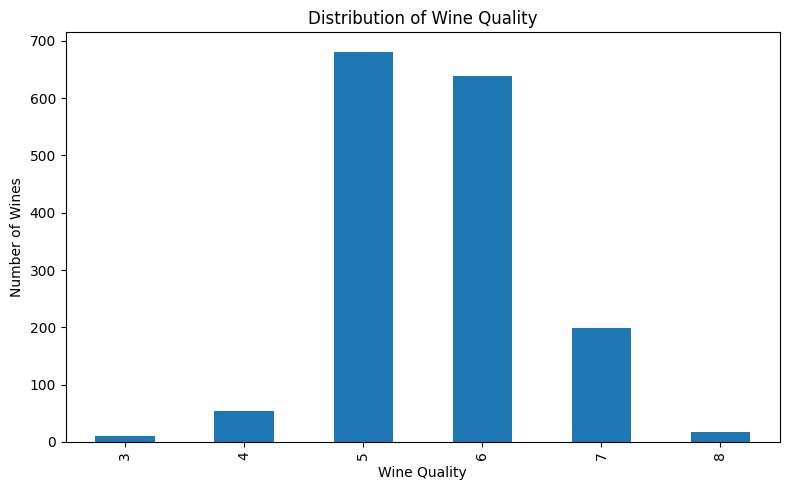

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df["quality"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.title("Distribution of Wine Quality")

plt.tight_layout()
plt.show()

In [ ]:
correlation = df.corr(numeric_only=True)

print(correlation)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.256131     0.671703   
volatile acidity          -0.256131          1.000000    -0.552496   
citric acid                0.671703         -0.552496     1.000000   
residual sugar             0.114777          0.001918     0.143577   
chlorides                  0.093705          0.061298     0.203823   
free sulfur dioxide       -0.153794         -0.010504    -0.060978   
total sulfur dioxide      -0.113181          0.076470     0.035533   
density                    0.668047          0.022026     0.364947   
pH                        -0.682978          0.234937    -0.541904   
sulphates                  0.183006         -0.260987     0.312770   
alcohol                   -0.061668         -0.202288     0.109903   
quality                    0.124052         -0.390558     0.226373   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

Dataset loaded successfully!
Dataset shape: (1599, 12)

Correlation values:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.256131     0.671703   
volatile acidity          -0.256131          1.000000    -0.552496   
citric acid                0.671703         -0.552496     1.000000   
residual sugar             0.114777          0.001918     0.143577   
chlorides                  0.093705          0.061298     0.203823   
free sulfur dioxide       -0.153794         -0.010504    -0.060978   
total sulfur dioxide      -0.113181          0.076470     0.035533   
density                    0.668047          0.022026     0.364947   
pH                        -0.682978          0.234937    -0.541904   
sulphates                  0.183006         -0.260987     0.312770   
alcohol                   -0.061668         -0.202288     0.109903   
quality                    0.124052         -0.390558     0.226373   

             

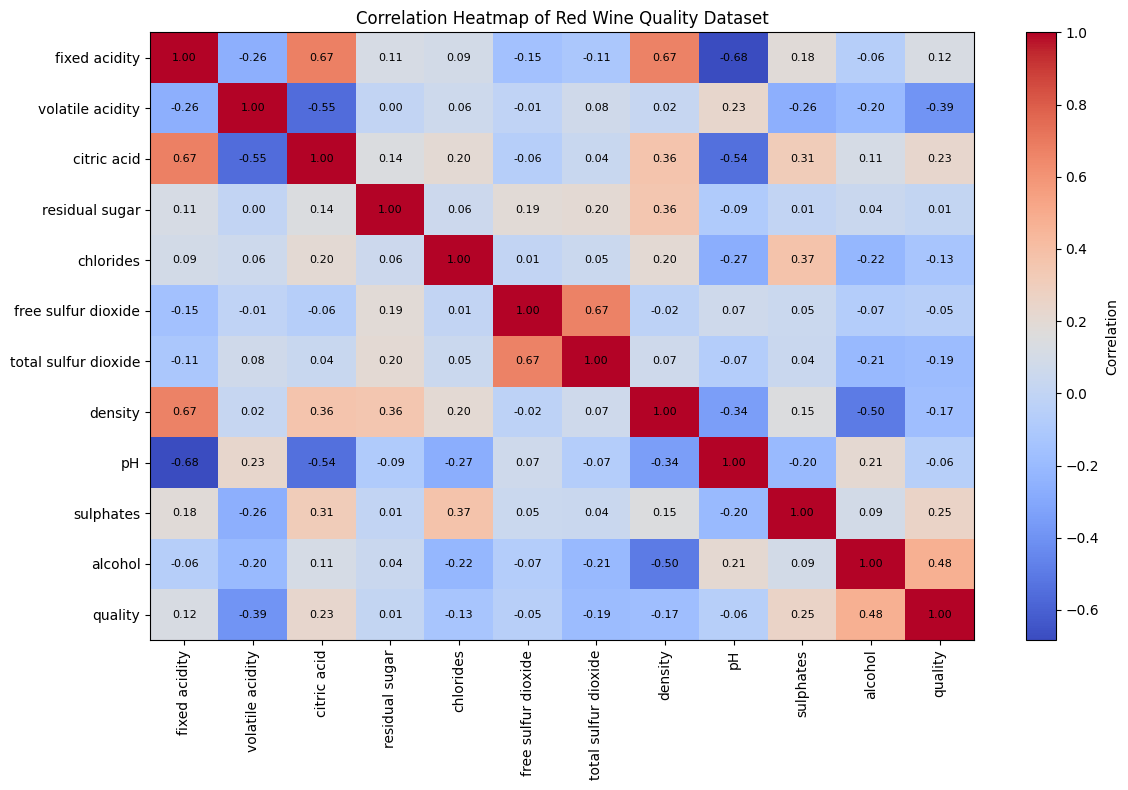

In [2]:
# ============================================
# CORRELATION HEATMAP - WINE QUALITY DATASET
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_excel("Red_Wine_Quality_Dataset.xlsx")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# 2. Calculate correlation
correlation = df.corr(numeric_only=True)

print("\nCorrelation values:")
print(correlation)

# 3. Create the heatmap
plt.figure(figsize=(12, 8))

plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto"
)

# 4. Add color bar
plt.colorbar(label="Correlation")

# 5. X-axis labels
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

# 6. Y-axis labels
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# 7. Add numbers inside each box
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

# 8. Title
plt.title("Correlation Heatmap of Red Wine Quality Dataset")

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=["quality"])
y = df["quality"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print("quality")

Input Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1279, 11)
Testing Data: (320, 11)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Prediction completed!")
print("\nFirst 20 Predictions:")
print(y_pred[:20])

Prediction completed!

First 20 Predictions:
[6 6 5 6 5 5 6 5 5 8 5 6 5 6 5 6 6 5 7 6]


In [ ]:
comparison = pd.DataFrame({
    "Actual Quality": y_test.values,
    "Predicted Quality": y_pred
})

print(comparison.head(20))

    Actual Quality  Predicted Quality
0                6                  6
1                5                  6
2                5                  5
3                5                  6
4                6                  5
5                6                  5
6                5                  6
7                4                  5
8                6                  5
9                8                  8
10               4                  5
11               6                  6
12               5                  5
13               4                  6
14               4                  5
15               6                  6
16               6                  6
17               5                  5
18               7                  7
19               5                  6


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Random Forest Accuracy: 0.678125
Accuracy Percentage: 67.8125 %


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  0   1   1   0   0   0]
 [  0   0   9   2   0   0]
 [  0   0 104  31   1   0]
 [  0   0  31  90   7   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]


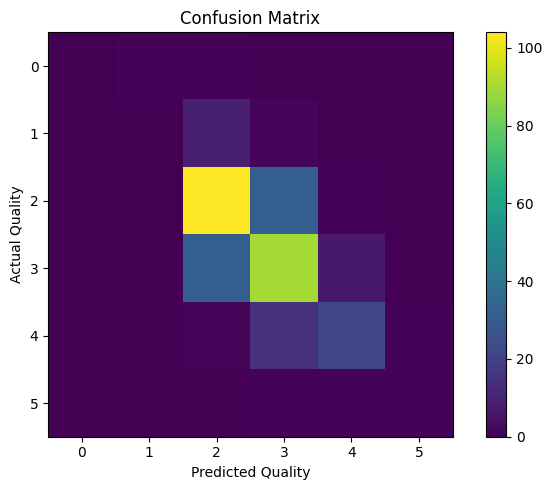

In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.title("Confusion Matrix")

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
                 Feature  Importance
10               alcohol    0.152106
9              sulphates    0.112057
1       volatile acidity    0.103678
6   total sulfur dioxide    0.101487
7                density    0.088812
4              chlorides    0.079941
8                     pH    0.079460
0          fixed acidity    0.076209
3         residual sugar    0.073386
2            citric acid    0.068562
5    free sulfur dioxide    0.064303


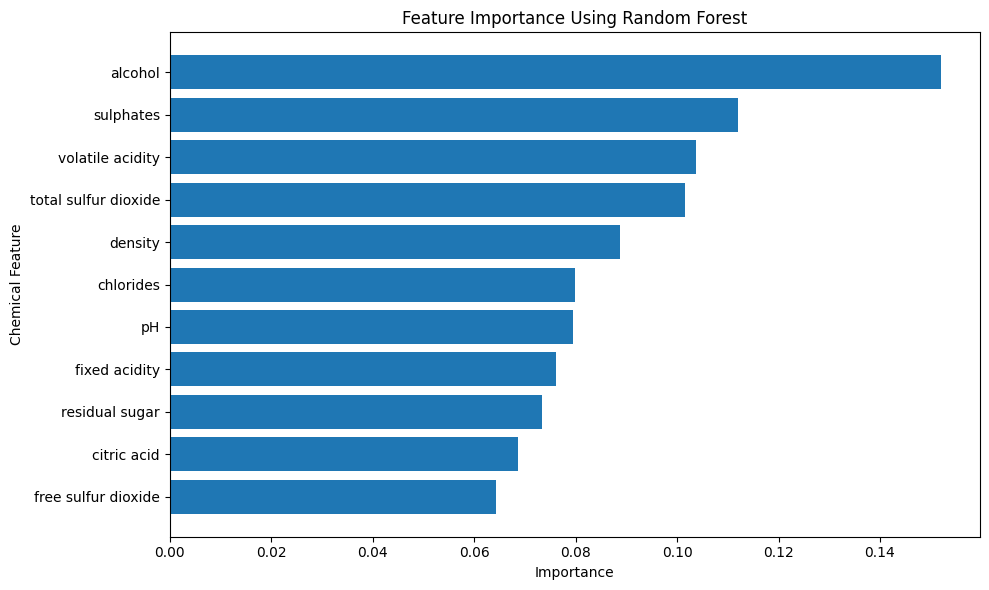

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Chemical Feature")
plt.title("Feature Importance Using Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

permutation_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
)

print(permutation_df)

                 Feature  Importance
10               alcohol    0.130625
9              sulphates    0.065937
1       volatile acidity    0.048125
6   total sulfur dioxide    0.021562
5    free sulfur dioxide    0.011875
4              chlorides    0.010312
2            citric acid    0.009687
8                     pH    0.008750
7                density    0.008437
3         residual sugar    0.006250
0          fixed acidity    0.001250


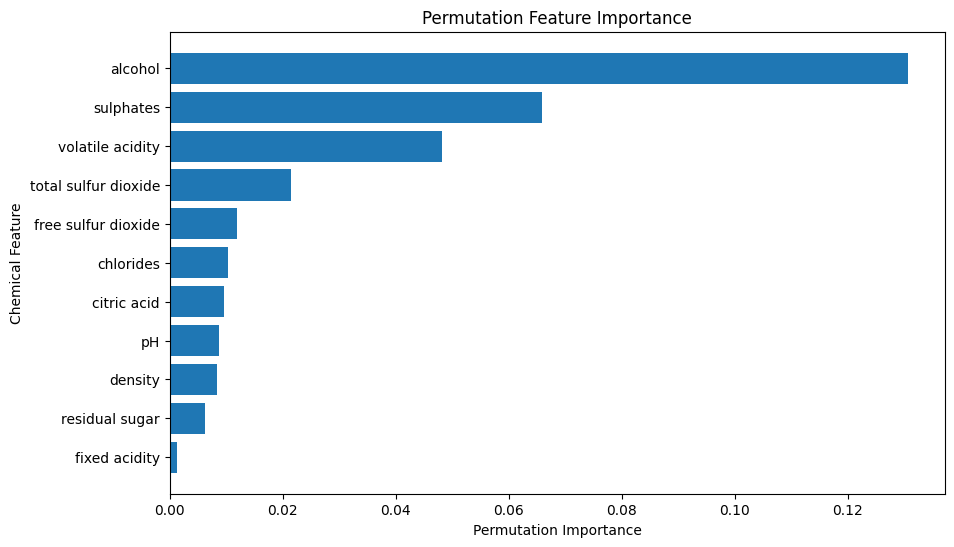

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    permutation_df["Feature"],
    permutation_df["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Chemical Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
feature_importance.to_excel(
    "Random_Forest_Feature_Importance.xlsx",
    index=False
)

permutation_df.to_excel(
    "Permutation_Feature_Importance.xlsx",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [ ]:
print("\n======================================")
print("FINAL FINDINGS")
print("======================================")

print(
    "Top feature:",
    feature_importance.iloc[0]["Feature"]
)

print(
    "Second important feature:",
    feature_importance.iloc[1]["Feature"]
)

print(
    "Third important feature:",
    feature_importance.iloc[2]["Feature"]
)

print(
    "\nRandom Forest Accuracy:",
    accuracy * 100,
    "%"
)

print("\nAlgorithm implementation completed successfully!")


FINAL FINDINGS
Top feature: alcohol
Second important feature: sulphates
Third important feature: volatile acidity

Random Forest Accuracy: 67.8125 %

Algorithm implementation completed successfully!
